# Spatial plots — GDE map clipped to the Ogallala Aquifer

Reads **`derived_usgs/GDE_30arcsec_Ogallala_CF.nc`** (CF-1.8, produced by
`extract_gde_ogallala.py`) and draws spatial maps of all five layers.

**Data:** Rohde et al. (2024), *Nature*, DOI 10.1038/s41586-024-07702-8
(global dryland groundwater-dependent ecosystem map, 30-arcsec aggregates;
see `G:\GDE map\README.pdf` §D). License CC BY 4.0 — cite Rohde et al. (2024).

**Requirements:** `xarray`, `numpy`, `matplotlib` (this env already has them).
The NetCDF is opened **read-only**; figures are written to `gde_spatial_plots/`.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path
import geopandas as gpd

In [2]:
# ---- config ----
NC_PATH = Path(r"G:/MSU_GWB/datasets/derived_usgs/GDE_30arcsec_Ogallala_CF.nc")
OUT_DIR = Path(r"G:/MSU_GWB/datasets/gde_spatial_plots")
SHP_PATH = Path(r"G:/MSU_GWB/datasets/high_plains_quifer/hp_bound2010.shp")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("input :", NC_PATH, "| exists:", NC_PATH.exists())
print("output:", OUT_DIR)

input : G:\MSU_GWB\datasets\derived_usgs\GDE_30arcsec_Ogallala_CF.nc | exists: True
output: G:\MSU_GWB\datasets\gde_spatial_plots


In [3]:
# ---- load (read-only, lazily) ----
ds = xr.open_dataset(NC_PATH, decode_cf=True)
print(ds)
print()
print("title:", ds.attrs.get("title"))
print("references:", ds.attrs.get("references"))
print("license:", ds.attrs.get("license"))

<xarray.Dataset> Size: 33MB
Dimensions:      (y: 1431, x: 1160)
Coordinates:
  * y            (y) float64 11kB 43.66 43.65 43.65 43.64 ... 31.76 31.75 31.75
  * x            (x) float64 9kB -105.9 -105.9 -105.9 ... -96.28 -96.27 -96.26
Data variables:
    crs          int32 4B ...
    GDE_sqm      (y, x) float32 7MB ...
    GDE_frac_AA  (y, x) float32 7MB ...
    GDE_frac_GA  (y, x) float32 7MB ...
    AA_sqm       (y, x) float32 7MB ...
    AA_frac_GA   (y, x) float32 7MB ...
Attributes: (12/15)
    Conventions:                CF-1.8
    title:                      Rohde et al. (2024) global GDE map, 30-arcsec...
    institution:                Rohde Environmental / U. Victoria (source dat...
    summary:                    Per-cell GDE area and analyzed-area layers fr...
    source:                     G:\MSU_GWB\datasets\GDE_30arcsec.tif (bands G...
    history:                    Created 2026-09-14 16:41:47 by extract_gde_og...
    ...                         ...
    geospatial_lat

In [4]:
# ---- ROI boundary for map overlays (hp_bound2010.shp) ----
bnd = gpd.read_file(SHP_PATH).to_crs("EPSG:4326")
print(f"boundary: {len(bnd)} polygon features, CRS {bnd.crs}")
print("bounds (lon/lat):", np.round(bnd.total_bounds, 3))

boundary: 199 polygon features, CRS EPSG:4326
bounds (lon/lat): [-105.921   31.743  -96.259   43.664]


In [5]:
# ---- summary statistics (computed on the small clipped grid) ----
layers = ["GDE_sqm", "GDE_frac_AA", "GDE_frac_GA", "AA_sqm", "AA_frac_GA"]
print(f"{'layer':<12} {'valid px':>10} {'min':>10} {'median':>10} {'max':>12}")
for name in layers:
    a = ds[name].values
    v = a[np.isfinite(a)]
    print(f"{name:<12} {v.size:>10,} {v.min():>10.4g} "
          f"{np.median(v):>10.4g} {v.max():>12.4g}")
total_gde_km2 = float(np.nansum(ds["GDE_sqm"].values)) / 1e6
print(f"\nTotal GDE area inside ROI: {total_gde_km2:,.1f} km^2")

layer          valid px        min     median          max
GDE_sqm         154,500          0  5.741e+04    7.236e+05
GDE_frac_AA     154,500          0     0.2528            1
GDE_frac_GA     154,500          0    0.08333            1


AA_sqm          154,500        692  4.684e+05    7.295e+05
AA_frac_GA      154,500   0.001111     0.6856            1

Total GDE area inside ROI: 21,005.3 km^2


In [6]:
# ---- shared map helper ----
def plot_layer(da, title, cmap="viridis", vmin=None, vmax=None,
               cbar_label="", figsize=(7.5, 7.0), norm=None,
               boundary=None, gridlines=True):
    """imshow of a 2-D DataArray on lon/lat extent (NaN = outside ROI).

    boundary: GeoDataFrame in EPSG:4326 whose outline is drawn on top.
    gridlines: faint dotted lon/lat grid.
    """
    x = da["x"].values
    y = da["y"].values
    dx = float(x[1] - x[0])
    dy = float(y[1] - y[0])  # negative: rows run north -> south
    extent = [x[0] - dx / 2, x[-1] + dx / 2, y[-1] + dy / 2, y[0] - dy / 2]
    fig, ax = plt.subplots(figsize=figsize)
    img = np.ma.masked_invalid(np.asarray(da.values, dtype="float64"))
    im = ax.imshow(img, extent=extent, origin="upper", cmap=cmap,
                   vmin=vmin, vmax=vmax, norm=norm, interpolation="nearest")
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")
    ax.set_title(title, fontsize=10)
    if gridlines:
        ax.grid(True, which="major", color="gray", alpha=0.35,
                linewidth=0.5, linestyle=":")
        ax.set_axisbelow(True)
    if boundary is not None:
        boundary.boundary.plot(ax=ax, edgecolor="black", linewidth=0.9)
    cb = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    cb.set_label(cbar_label)
    fig.tight_layout()
    return fig, ax

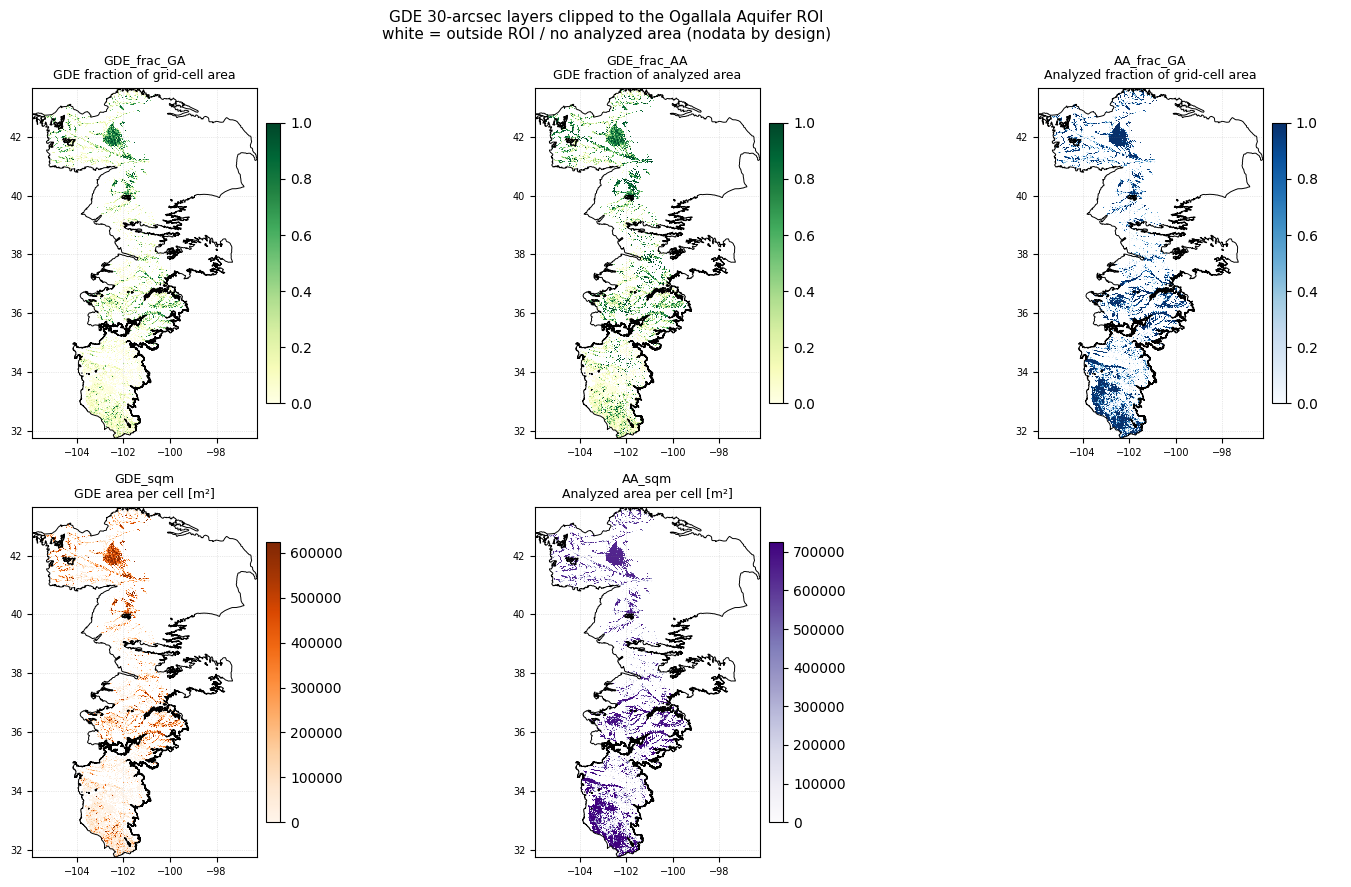

In [7]:
# ---- overview panel: all five layers ----
specs = [
    ("GDE_frac_GA", "GDE fraction of grid-cell area", "YlGn", 0, 1),
    ("GDE_frac_AA", "GDE fraction of analyzed area", "YlGn", 0, 1),
    ("AA_frac_GA",  "Analyzed fraction of grid-cell area", "Blues", 0, 1),
    ("GDE_sqm",     "GDE area per cell [m²]", "Oranges", 0,
     float(np.nanpercentile(ds["GDE_sqm"].values, 99))),
    ("AA_sqm",      "Analyzed area per cell [m²]", "Purples", 0,
     float(np.nanpercentile(ds["AA_sqm"].values, 99))),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, title, cmap, vmin, vmax) in zip(axes.flat, specs):
    da = ds[name]
    x = da["x"].values
    y = da["y"].values
    dx = float(x[1] - x[0]); dy = float(y[1] - y[0])
    extent = [x[0] - dx / 2, x[-1] + dx / 2, y[-1] + dy / 2, y[0] - dy / 2]
    img = np.ma.masked_invalid(np.asarray(da.values, dtype="float64"))
    im = ax.imshow(img, extent=extent, origin="upper", cmap=cmap,
                   vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(f"{name}\n{title}", fontsize=9)
    bnd.boundary.plot(ax=ax, edgecolor="black", linewidth=0.7)
    ax.grid(True, which="major", color="gray", alpha=0.35,
            linewidth=0.5, linestyle=":")
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=7)
    fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
axes.flat[-1].axis("off")  # empty 6th slot
fig.suptitle("GDE 30-arcsec layers clipped to the Ogallala Aquifer ROI\n"
             "white = outside ROI / no analyzed area (nodata by design)",
             fontsize=11)
fig.tight_layout()
fig.savefig(OUT_DIR / "gde_overview_panel.png", dpi=150)
plt.show()

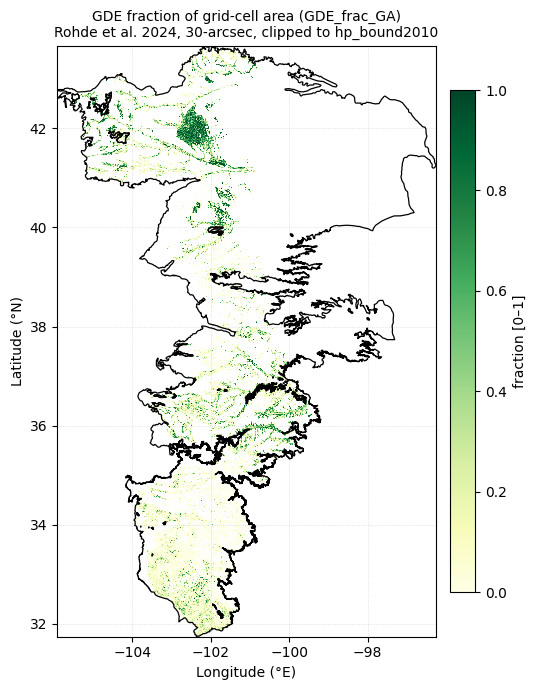

In [8]:
# ---- detailed map: GDE fraction of grid-cell area ----
fig, ax = plot_layer(
    ds["GDE_frac_GA"],
    "GDE fraction of grid-cell area (GDE_frac_GA)\n"
    "Rohde et al. 2024, 30-arcsec, clipped to hp_bound2010",
    cmap="YlGn", vmin=0, vmax=1, boundary=bnd, cbar_label="fraction [0–1]")
fig.savefig(OUT_DIR / "gde_frac_GA_map.png", dpi=150)
plt.show()

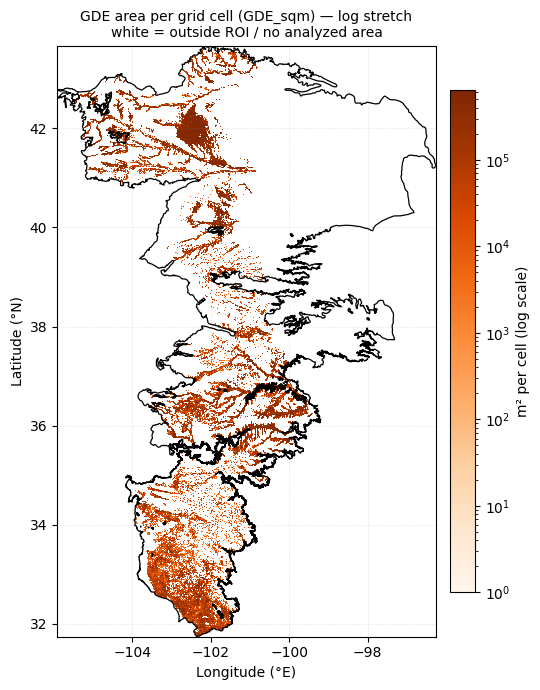

In [9]:
# ---- detailed map: GDE area per cell (log stretch for skewed areas) ----
fig, ax = plot_layer(
    ds["GDE_sqm"],
    "GDE area per grid cell (GDE_sqm) — log stretch\n"
    "white = outside ROI / no analyzed area",
    cmap="Oranges", boundary=bnd, norm=LogNorm(vmin=1.0,
        vmax=float(np.nanpercentile(ds["GDE_sqm"].values, 99.5))),
    cbar_label="m² per cell (log scale)")
fig.savefig(OUT_DIR / "gde_sqm_map.png", dpi=150)
plt.show()

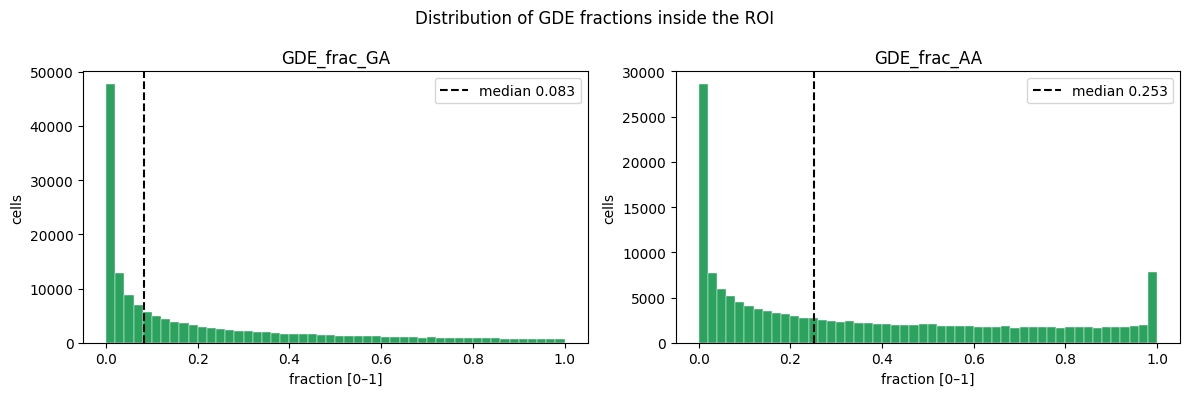

In [10]:
# ---- histograms of the fraction layers ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, ["GDE_frac_GA", "GDE_frac_AA"]):
    v = ds[name].values[np.isfinite(ds[name].values)]
    ax.hist(v, bins=50, color="#2ca25f", edgecolor="white", linewidth=0.3)
    ax.axvline(np.median(v), color="k", linestyle="--",
               label=f"median {np.median(v):.3f}")
    ax.set_title(name)
    ax.set_xlabel("fraction [0–1]")
    ax.set_ylabel("cells")
    ax.legend()
fig.suptitle("Distribution of GDE fractions inside the ROI")
fig.tight_layout()
fig.savefig(OUT_DIR / "gde_fraction_histograms.png", dpi=150)
plt.show()

**Notes for interpretation**

- White areas are *outside* the `hp_bound2010` polygon **or** cells with no
  analyzed area in the source product (nodata by design — much of the eastern,
  sub-humid part of the aquifer lies outside the GDE model domain).
- `GDE_frac_GA` (mean ~0.20) is the grid-cell view useful for overlays with
  other gridded layers; `GDE_frac_AA` (median ~0.25) is conditional on analyzed
  area only.
- The grid is the product's **native 30-arcsec** lattice (not resampled to the
  4 km TBI grid) — see `TBI_DOCUMENTATION.md` §11.14 for provenance and caveats.

In [11]:
# ---- wrap-up ----
ds.close()
print("saved figures:")
for p in sorted(OUT_DIR.glob("*.png")):
    print(f"  {p.name}  ({p.stat().st_size/1e3:.0f} KB)")

saved figures:
  gde_frac_GA_map.png  (298 KB)
  gde_fraction_histograms.png  (48 KB)
  gde_overview_panel.png  (641 KB)
  gde_sqm_map.png  (285 KB)
